In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import get_data
import matplotlib.pyplot as plt
import population_activity as pop
import helper_functions as hf
import analysis
import plots
import statistics_test as st
import simulate_network_downstream as sim_net
import decoding2 as decoding2

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path

OUT = Path("figures"); OUT.mkdir(exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [15]:
datapaths = ['D:/Antje_CA1/data_sig/170.h5', 'D:/Antje_CA1/data_sig/51004.h5', 'D:/Antje_CA1/data_sig/51007.h5',
             'D:/Antje_CA1/data_sig/63.h5', 'D:/Antje_CA1/data_sig/64.h5', 'D:/Antje_CA1/data_sig/65.h5']
day = '0'
context = 'Context1'
noise_levels = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

results = [sim_net.simulate_inverse_noise(dp, day, context,
                                          inverse_eps_levels=noise_levels,
                                          inverse_noise_model='additive')
           for dp in datapaths]



In [16]:
mae_values_original = []
mae_values_controlled_0_5 = []
mae_values_controlled_0_75 = []
mae_values_controlled_1 = []
mae_values_rotation = []

for res in results:
    mae_list_original = []
    mae_list_controlled_0_5 = []
    mae_list_controlled_0_75 = []
    mae_list_controlled_1 = []
    mae_list_rotation = []
    
    for key in noise_levels:
        mae_list_original.append(res['original']['final'][key]['mae'])
        mae_list_controlled_0_5.append(res['controlled_0.8']['final'][key]['mae'])
        mae_list_controlled_0_75.append(res['controlled_0.9']['final'][key]['mae'])
        mae_list_controlled_1.append(res['controlled_1']['final'][key]['mae'])
        mae_list_rotation.append(res['rotation']['final'][key]['mae'])
    
    mae_values_original.append(mae_list_original)
    mae_values_controlled_0_5.append(mae_list_controlled_0_5)
    mae_values_controlled_0_75.append(mae_list_controlled_0_75)
    mae_values_controlled_1.append(mae_list_controlled_1)
    mae_values_rotation.append(mae_list_rotation)

mae_array_original = np.array(mae_values_original)
mae_array_controlled_0_5 = np.array(mae_values_controlled_0_5)
mae_array_controlled_0_75 = np.array(mae_values_controlled_0_75)
mae_array_controlled_1 = np.array(mae_values_controlled_1)
mae_array_rotation = np.array(mae_values_rotation)

C:\Users\Ole\AppData\Local\Temp\ipykernel_18472\250697927.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


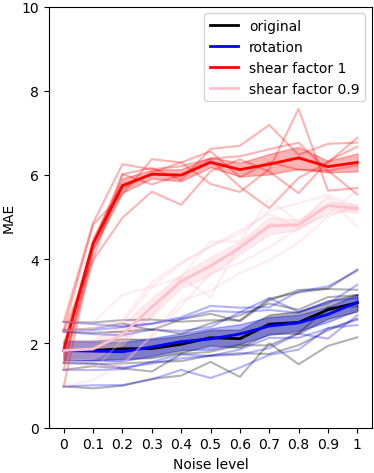

c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,18.861299,10,50,1.886130,82.760155,1.477876e-27,1.109540e-09,0.332970,0.304693
1,condition,0.000874,1,5,0.000874,0.051443,8.295530e-01,8.295530e-01,0.000023,1.000000
2,time * condition,0.114630,10,50,0.011463,0.647909,7.657032e-01,5.677244e-01,0.003025,0.241031


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,0.7426,0.4911,1.0000,,0.3032,Cohen's d,1.8357,1.8182,0.0174,0.0575,6,True,0.5605
2,T3,C1,C2,t-test,2.9081,0.0335,0.3347,,1.1872,Cohen's d,1.8740,1.8035,0.0705,0.0594,6,True,0.7901
3,T4,C1,C2,t-test,-0.7405,0.4923,1.0000,,-0.3023,Cohen's d,1.8792,1.9167,-0.0375,0.1240,6,True,0.2484
4,T5,C1,C2,t-test,-2.8925,0.0341,0.3409,,-1.1809,Cohen's d,1.9817,2.0447,-0.0630,0.0534,6,True,0.8228
5,T6,C1,C2,t-test,0.2999,0.7763,1.0000,,0.1224,Cohen's d,2.1365,2.1076,0.0289,0.2363,6,True,0.8335
6,T7,C1,C2,t-test,-1.7269,0.1448,1.0000,,-0.7050,Cohen's d,2.1137,2.2256,-0.1119,0.1587,6,True,0.5930
7,T8,C1,C2,t-test,0.5568,0.6017,1.0000,,0.2273,Cohen's d,2.4580,2.4141,0.0439,0.1933,6,True,0.3807
8,T9,C1,C2,t-test,0.0764,0.9421,1.0000,,0.0312,Cohen's d,2.4991,2.4894,0.0097,0.3116,6,True,0.6595
9,T10,C1,C2,t-test,0.8369,0.4408,1.0000,,0.3417,Cohen's d,2.8014,2.6904,0.1110,0.3249,6,True,0.8917


c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,85.743493,10,50,8.574349,129.628773,3.616758e-32,1.438028e-11,0.719681,0.320256
1,condition,70.488166,1,5,70.488166,317.333825,1.023200e-05,1.023200e-05,0.678517,1.000000
2,time * condition,27.989904,10,50,2.798990,65.362219,3.495565e-25,6.056477e-08,0.455956,0.262044


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,-0.7393,0.4929,1.0000,,-0.3018,Cohen's d,1.8357,1.8681,-0.0324,0.1075,6,True,0.6032
2,T3,C1,C2,t-test,-2.7366,0.0410,0.4096,,-1.1172,Cohen's d,1.8740,2.2117,-0.3377,0.3023,6,True,0.4120
3,T4,C1,C2,t-test,-9.9439,0.0002,0.0018,**,-4.0596,Cohen's d,1.8792,2.8659,-0.9867,0.2431,6,True,0.9377
4,T5,C1,C2,t-test,-18.8361,7.7683e-06,7.7683e-05,***,-7.6898,Cohen's d,1.9817,3.4766,-1.4949,0.1944,6,True,0.0676
5,T6,C1,C2,t-test,-14.2030,3.1161e-05,0.0003,***,-5.7983,Cohen's d,2.1365,3.8418,-1.7053,0.2941,6,True,0.9675
6,T7,C1,C2,t-test,-15.3871,2.1041e-05,0.0002,***,-6.2818,Cohen's d,2.1137,4.2727,-2.1589,0.3437,6,True,0.8607
7,T8,C1,C2,t-test,-18.4464,8.6133e-06,8.6133e-05,***,-7.5307,Cohen's d,2.4580,4.7897,-2.3317,0.3096,6,True,0.4413
8,T9,C1,C2,t-test,-9.8944,0.0002,0.0018,**,-4.0394,Cohen's d,2.4991,4.8177,-2.3186,0.5740,6,True,0.9081
9,T10,C1,C2,t-test,-13.0794,4.6617e-05,0.0005,***,-5.3396,Cohen's d,2.8014,5.2737,-2.4723,0.4630,6,True,0.9891


c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,77.799229,10,50,7.779923,64.112501,5.442342e-25,1.776305e-08,0.702759,0.286888
1,condition,377.015385,1,5,377.015385,436.200107,4.661017e-06,4.661017e-06,0.919726,1.000000
2,time * condition,44.505115,10,50,4.450512,43.145127,4.012499e-21,2.294892e-07,0.574918,0.287356


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,-11.9194,7.3253e-05,0.0007,***,-4.8661,Cohen's d,1.8357,4.3723,-2.5366,0.5213,6,True,0.8173
2,T3,C1,C2,t-test,-14.7987,2.5479e-05,0.0003,***,-6.0415,Cohen's d,1.8740,5.7496,-3.8756,0.6415,6,True,0.3797
3,T4,C1,C2,t-test,-21.5729,3.9702e-06,3.9702e-05,***,-8.8071,Cohen's d,1.8792,6.0188,-4.1396,0.4700,6,True,0.7985
4,T5,C1,C2,wilcoxon,0.0000,0.0312,0.3125,,0.8987,r,1.9817,5.9965,-4.0148,0.5620,6,False,0.0119
5,T6,C1,C2,t-test,-35.9880,3.1184e-07,3.1184e-06,***,-14.6920,Cohen's d,2.1365,6.3010,-4.1645,0.2835,6,True,0.6416
6,T7,C1,C2,t-test,-22.9261,2.9366e-06,2.9366e-05,***,-9.3595,Cohen's d,2.1137,6.1286,-4.0149,0.4290,6,True,0.9427
7,T8,C1,C2,t-test,-18.9735,7.4943e-06,7.4943e-05,***,-7.7459,Cohen's d,2.4580,6.2564,-3.7984,0.4904,6,True,0.1420
8,T9,C1,C2,wilcoxon,0.0000,0.0312,0.3125,,0.8987,r,2.4991,6.4061,-3.9069,1.1033,6,False,0.0129
9,T10,C1,C2,t-test,-16.7946,1.3680e-05,0.0001,***,-6.8564,Cohen's d,2.8014,6.1983,-3.3970,0.4954,6,True,0.3155


In [19]:
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_anova([mae_array_original, mae_array_rotation, mae_array_controlled_1, mae_array_controlled_0_75], noise_levels, colors=['k', 'b', 'r', 'pink'], 
                          labels=['original', 'rotation', 'shear factor 1', 'shear factor 0.9'], 
                          plot_individual=True, ylim=[0, 10], ax=ax, xlabel='Noise level', ylabel='MAE')
fig.tight_layout()
fig.savefig(OUT / "inverse_noise.eps", format="eps")
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA Rotation')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_rotation])
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 0.9')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_controlled_0_75])
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 1')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_controlled_1])
display(anova[0])
display(anova[1])

In [ ]:
datapaths = ['D:/Antje_CA1/data_sig/170.h5', 'D:/Antje_CA1/data_sig/51004.h5', 'D:/Antje_CA1/data_sig/51007.h5',
             'D:/Antje_CA1/data_sig/63.h5', 'D:/Antje_CA1/data_sig/64.h5', 'D:/Antje_CA1/data_sig/65.h5']
day = '0'
context = 'Context1'
noise_levels = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

results = [sim_net.simulate_within_animal_blend(
              datapath, day, context,
              noise_levels=noise_levels,
              shear_factors=[0.8, 0.9, 1],
              time_shift=False,       
              random_state=123
          ) for datapath in datapaths]


In [14]:
mae_values_original = []
mae_values_controlled_0_5 = []
mae_values_controlled_0_75 = []
mae_values_controlled_1 = []
mae_values_rotation = []

for res in results:
    mae_list_original = []
    mae_list_controlled_0_5 = []
    mae_list_controlled_0_75 = []
    mae_list_controlled_1 = []
    mae_list_rotation = []
    
    for key in noise_levels:
        mae_list_original.append(res['original']['final'][key]['mae'])
        mae_list_controlled_0_5.append(res['controlled_0.8']['final'][key]['mae'])
        mae_list_controlled_0_75.append(res['controlled_0.9']['final'][key]['mae'])
        mae_list_controlled_1.append(res['controlled_1']['final'][key]['mae'])
        mae_list_rotation.append(res['rotation']['final'][key]['mae'])
    
    mae_values_original.append(mae_list_original)
    mae_values_controlled_0_5.append(mae_list_controlled_0_5)
    mae_values_controlled_0_75.append(mae_list_controlled_0_75)
    mae_values_controlled_1.append(mae_list_controlled_1)
    mae_values_rotation.append(mae_list_rotation)

mae_array_original = np.array(mae_values_original)
mae_array_controlled_0_5 = np.array(mae_values_controlled_0_5)
mae_array_controlled_0_75 = np.array(mae_values_controlled_0_75)
mae_array_controlled_1 = np.array(mae_values_controlled_1)
mae_array_rotation = np.array(mae_values_rotation)

C:\Users\Ole\AppData\Local\Temp\ipykernel_24484\691227616.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


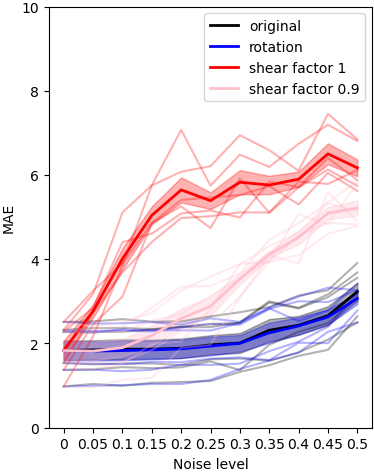

c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,22.144437,10,50,2.214444,75.895770,1.110108e-26,3.153827e-07,0.361733,0.218003
1,condition,0.043110,1,5,0.043110,1.616467,2.595166e-01,2.595166e-01,0.001102,1.000000
2,time * condition,0.060985,10,50,0.006098,0.563328,8.355512e-01,6.285539e-01,0.001558,0.264990


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,2.0734,0.0928,0.9284,,0.8465,Cohen's d,1.8472,1.8195,0.0277,0.0327,6,True,0.6683
2,T3,C1,C2,t-test,1.2299,0.2734,1.0000,,0.5021,Cohen's d,1.8633,1.8320,0.0313,0.0624,6,True,0.5208
3,T4,C1,C2,t-test,1.4098,0.2177,1.0000,,0.5755,Cohen's d,1.8660,1.8474,0.0186,0.0323,6,True,0.5266
4,T5,C1,C2,t-test,0.5061,0.6343,1.0000,,0.2066,Cohen's d,1.8859,1.8721,0.0138,0.0667,6,True,0.3236
5,T6,C1,C2,t-test,0.8382,0.4401,1.0000,,0.3422,Cohen's d,1.9666,1.9384,0.0282,0.0825,6,True,0.8057
6,T7,C1,C2,t-test,0.1342,0.8985,1.0000,,0.0548,Cohen's d,2.0111,2.0039,0.0071,0.1302,6,True,0.7808
7,T8,C1,C2,t-test,1.3142,0.2458,1.0000,,0.5365,Cohen's d,2.3138,2.2531,0.0608,0.1133,6,True,0.4787
8,T9,C1,C2,t-test,0.1864,0.8595,1.0000,,0.0761,Cohen's d,2.4315,2.4153,0.0162,0.2132,6,True,0.5727
9,T10,C1,C2,t-test,0.2918,0.7822,1.0000,,0.1191,Cohen's d,2.6594,2.6288,0.0305,0.2562,6,True,0.4180


c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,89.859017,10,50,8.985902,190.623148,3.320485e-36,2.595297e-08,0.712916,0.189220
1,condition,37.887541,1,5,37.887541,170.086256,4.727757e-05,4.727757e-05,0.511490,1.000000
2,time * condition,25.819835,10,50,2.581984,40.344954,1.746081e-20,6.707327e-07,0.416414,0.272603


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,1.1920,0.2868,1.0000,,0.4866,Cohen's d,1.8472,1.8186,0.0286,0.0587,6,True,0.3081
2,T3,C1,C2,t-test,-1.3204,0.2439,1.0000,,-0.5391,Cohen's d,1.8633,1.9013,-0.0380,0.0705,6,True,0.9965
3,T4,C1,C2,t-test,-4.3844,0.0071,0.0712,,-1.7899,Cohen's d,1.8660,2.1877,-0.3217,0.1797,6,True,0.3845
4,T5,C1,C2,t-test,-7.6215,0.0006,0.0062,**,-3.1115,Cohen's d,1.8859,2.5925,-0.7066,0.2271,6,True,0.4434
5,T6,C1,C2,t-test,-11.6956,8.0309e-05,0.0008,***,-4.7747,Cohen's d,1.9666,2.8850,-0.9184,0.1923,6,True,0.8155
6,T7,C1,C2,t-test,-6.6627,0.0011,0.0115,*,-2.7200,Cohen's d,2.0111,3.5309,-1.5198,0.5587,6,True,0.1247
7,T8,C1,C2,t-test,-7.1802,0.0008,0.0082,**,-2.9313,Cohen's d,2.3138,4.1172,-1.8033,0.6152,6,True,0.7634
8,T9,C1,C2,t-test,-11.7846,7.7409e-05,0.0008,***,-4.8111,Cohen's d,2.4315,4.5188,-2.0874,0.4339,6,True,0.9422
9,T10,C1,C2,t-test,-8.2157,0.0004,0.0044,**,-3.3541,Cohen's d,2.6594,5.0940,-2.4347,0.7259,6,True,0.1677


c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,96.779525,10,50,9.677953,87.302019,4.233879e-28,3.196561e-07,0.696060,0.206126
1,condition,261.115988,1,5,261.115988,97.519937,1.815521e-04,1.815521e-04,0.860702,1.000000
2,time * condition,48.738285,10,50,4.873828,45.317773,1.356703e-21,9.266229e-07,0.535598,0.250410


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,1.8333,1.8333,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,t-test,-8.9729,0.0003,0.0029,**,-3.6632,Cohen's d,1.8472,2.7701,-0.9229,0.2519,6,True,0.6071
2,T3,C1,C2,t-test,-8.8578,0.0003,0.0030,**,-3.6162,Cohen's d,1.8633,4.0101,-2.1468,0.5937,6,True,0.6994
3,T4,C1,C2,t-test,-8.7223,0.0003,0.0033,**,-3.5609,Cohen's d,1.8660,5.0408,-3.1748,0.8916,6,True,0.4229
4,T5,C1,C2,t-test,-9.4964,0.0002,0.0022,**,-3.8769,Cohen's d,1.8859,5.6459,-3.7600,0.9699,6,True,0.4677
5,T6,C1,C2,t-test,-8.1210,0.0005,0.0046,**,-3.3154,Cohen's d,1.9666,5.3902,-3.4236,1.0326,6,True,0.8779
6,T7,C1,C2,t-test,-8.7965,0.0003,0.0032,**,-3.5912,Cohen's d,2.0111,5.8282,-3.8172,1.0629,6,True,0.7892
7,T8,C1,C2,t-test,-8.6998,0.0003,0.0033,**,-3.5517,Cohen's d,2.3138,5.7617,-3.4479,0.9708,6,True,0.7969
8,T9,C1,C2,t-test,-11.4687,8.8308e-05,0.0009,***,-4.6821,Cohen's d,2.4315,5.8996,-3.4681,0.7407,6,True,0.4554
9,T10,C1,C2,t-test,-9.9529,0.0002,0.0017,**,-4.0633,Cohen's d,2.6594,6.5018,-3.8425,0.9457,6,True,0.2330


In [15]:
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_anova([mae_array_original, mae_array_rotation, mae_array_controlled_1, mae_array_controlled_0_75], noise_levels, colors=['k', 'b', 'r', 'pink'], 
                          labels=['original', 'rotation', 'shear factor 1', 'shear factor 0.9'], 
                          plot_individual=True, ylim=[0, 10], ax=ax, xlabel='Noise level', ylabel='MAE')
fig.tight_layout()
fig.savefig(OUT / "permutation_noise.eps", format="eps")
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA Rotation')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_rotation])
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 0.9')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_controlled_0_75])
display(anova[0])
display(anova[1])

print_large('\nTWO-WAY REPEATED ANOVA shear factor 1')
anova=st.repeated_measures_anova_general([mae_array_original,mae_array_controlled_1])
display(anova[0])
display(anova[1])